# Autoencoders
### From PCA to learned representations

You already know how to compress data: PCA finds the directions of maximum variance and projects onto them. You know how to measure similarity: distances in original or reduced spaces. You know that lower-dimensional representations can reveal clusters, neighbours, and structure that are invisible in the raw features.

Autoencoders do the same thing — **compress, then reconstruct** — but they replace PCA's linear algebra with a neural network. This single change unlocks non-linear manifolds, learned features, denoising, and even data generation.

This lecture builds the idea in four steps:

1. **PCA as a neural network** — to see that you already understand autoencoders conceptually
2. **Non-linear autoencoders** — what changes when we add activation functions
3. **Denoising autoencoders** — learning robust representations by training on corrupted inputs
4. **Variational autoencoders (VAE)** — from compression to generation

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE

plt.rcParams['figure.dpi'] = 110
np.random.seed(42)
torch.manual_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using: {device}")

Using: cpu


---
## The dataset: Fashion-MNIST

We use Fashion-MNIST throughout this lecture: 70,000 grayscale images of clothing items (28×28 pixels = 784 dimensions). Each image belongs to one of 10 categories. It's high-dimensional enough that compression is meaningful, and visual enough that we can *see* what the models learn.

In [6]:
import os, gzip, struct, urllib.request
import numpy as np

def fetch_fmnist(path='./data/fmnist'):
    os.makedirs(path, exist_ok=True)
    base = 'http://fashion-mnist.s3-website.eu-central-1.amazonaws.com/'
    files = {'train_img': 'train-images-idx3-ubyte.gz',
             'train_lab': 'train-labels-idx1-ubyte.gz',
             'test_img':  't10k-images-idx3-ubyte.gz',
             'test_lab':  't10k-labels-idx1-ubyte.gz'}
    for key, fn in files.items():
        fp = os.path.join(path, fn)
        if not os.path.exists(fp):
            print(f'Downloading {fn}...')
            urllib.request.urlretrieve(base + fn, fp)
    
    def read_imgs(f):
        with gzip.open(f, 'rb') as g:
            _, n, r, c = struct.unpack('>4I', g.read(16))
            return np.frombuffer(g.read(), dtype=np.uint8).reshape(n, r * c)
    
    def read_labs(f):
        with gzip.open(f, 'rb') as g:
            struct.unpack('>2I', g.read(8))
            return np.frombuffer(g.read(), dtype=np.uint8)
    
    return (read_imgs(os.path.join(path, files['train_img'])),
            read_labs(os.path.join(path, files['train_lab'])),
            read_imgs(os.path.join(path, files['test_img'])),
            read_labs(os.path.join(path, files['test_lab'])))

X_tr, y_tr, X_te, y_te = fetch_fmnist()
X_train = torch.tensor(X_tr, dtype=torch.float32) / 255.0
X_test  = torch.tensor(X_te, dtype=torch.float32) / 255.0
y_train, y_test = y_tr, y_te

class_names = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Boot']

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")

Train: torch.Size([60000, 784])  |  Test: torch.Size([10000, 784])


---
## 1. PCA is already an autoencoder

Let's recall what PCA does. Given a 784-dimensional image, PCA:
1. **Encodes** it into a lower-dimensional vector (say, 32 numbers) by projecting onto the top principal components
2. **Decodes** it back to 784 dimensions by multiplying with the transposed components

This is exactly the **encode → bottleneck → decode** structure. The only constraint is linearity: both the encoder and decoder are matrix multiplications.

Let's see how well PCA compresses these images.

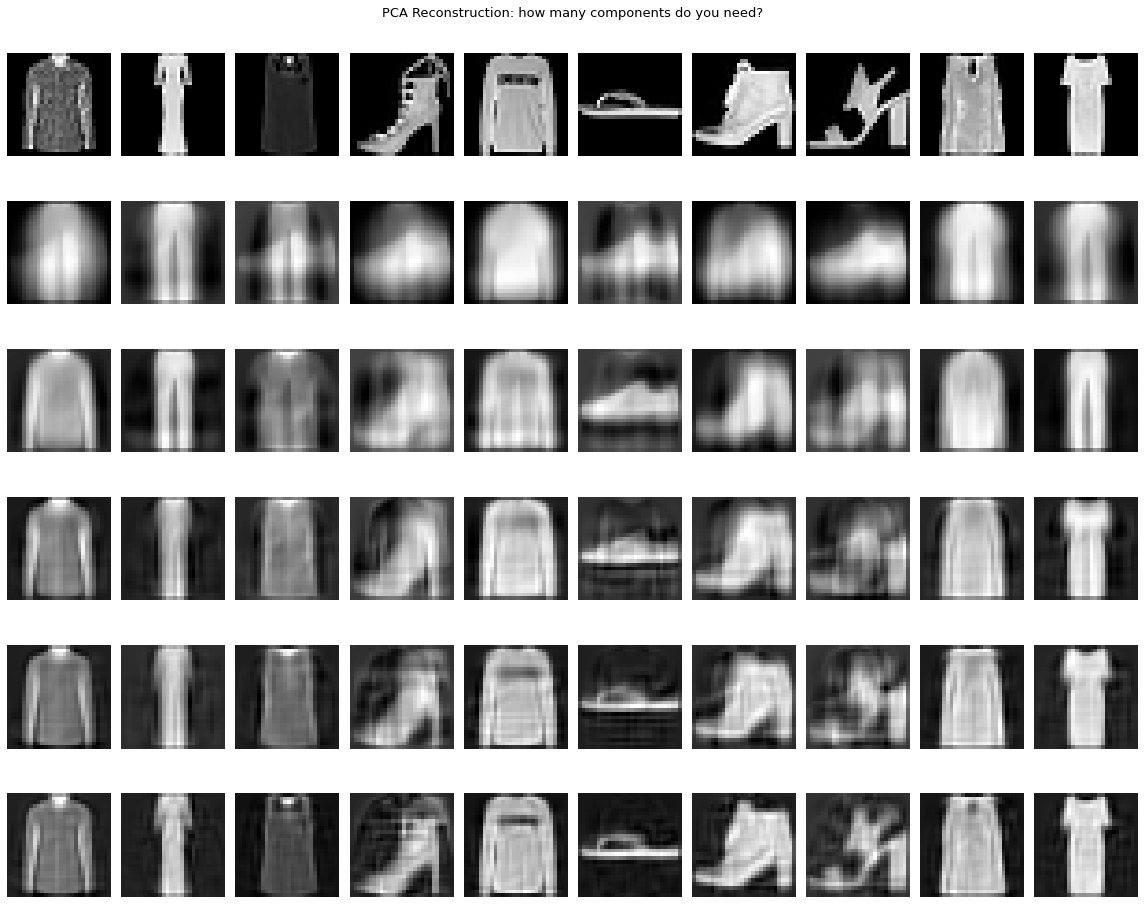

In [7]:
# PCA reconstruction at different bottleneck sizes
dims = [2, 8, 32, 64, 128]

fig, axes = plt.subplots(len(dims) + 1, 10, figsize=(16, 2.2 * (len(dims) + 1)))

# Original
sample_idx = np.random.choice(len(X_test), 10, replace=False)
for i in range(10):
    axes[0, i].imshow(X_test[sample_idx[i]].reshape(28, 28), cmap='gray')
    axes[0, i].axis('off')
    if i == 0: axes[0, i].set_ylabel('Original', fontsize=10, rotation=0, labelpad=55)

# Reconstructions
for row, d in enumerate(dims):
    pca = PCA(n_components=d)
    Z = pca.fit_transform(X_train.numpy())
    Z_test = pca.transform(X_test.numpy())
    X_recon = pca.inverse_transform(Z_test)
    
    mse = np.mean((X_test.numpy() - X_recon) ** 2)
    var = sum(pca.explained_variance_ratio_) * 100
    
    for i in range(10):
        axes[row+1, i].imshow(X_recon[sample_idx[i]].reshape(28, 28), cmap='gray')
        axes[row+1, i].axis('off')
    axes[row+1, 0].set_ylabel(f'd={d}\n({var:.0f}% var)', fontsize=9, rotation=0, labelpad=55)

plt.suptitle('PCA Reconstruction: how many components do you need?', fontsize=13)
plt.tight_layout(); plt.show()

With 32 components we retain ~80% of variance and the reconstructions look reasonable. With 2 components it's a blurry mess — most of the information is lost. But PCA is constrained to **linear** projections. The real structure of clothing images (curves, edges, textures) lives on a non-linear manifold that PCA can only approximate with flat hyperplanes.

### PCA as a neural network

To make the connection explicit, let's implement PCA as a single-layer neural network with no activation function. The encoder is a matrix $W_e \in \mathbb{R}^{784 \times d}$, the decoder is $W_d \in \mathbb{R}^{d \times 784}$, and the loss is mean squared error between input and reconstruction:

$$\mathbf{z} = \mathbf{x} \cdot W_e \qquad \hat{\mathbf{x}} = \mathbf{z} \cdot W_d \qquad \mathcal{L} = \|\mathbf{x} - \hat{\mathbf{x}}\|^2$$

If we train this network, the learned weights $W_e$ will span the same subspace as the top PCA components. Let's verify.

In [8]:
class LinearAutoencoder(nn.Module):
    """No activation functions — this is PCA implemented as a neural network."""
    def __init__(self, input_dim, latent_dim):
        super().__init__()
        self.encoder = nn.Linear(input_dim, latent_dim, bias=False)
        self.decoder = nn.Linear(latent_dim, input_dim, bias=False)
    
    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z), z

# Train with d=32, same as our PCA above
latent_dim = 32
model_lin = LinearAutoencoder(784, latent_dim).to(device)
optimizer = optim.Adam(model_lin.parameters(), lr=1e-3)

loader = DataLoader(TensorDataset(X_train), batch_size=256, shuffle=True)

losses = []
for epoch in range(30):
    epoch_loss = 0
    for (batch,) in loader:
        batch = batch.to(device)
        recon, _ = model_lin(batch)
        loss = nn.MSELoss()(recon, batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * len(batch)
    losses.append(epoch_loss / len(X_train))
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d}  loss = {losses[-1]:.5f}")

Epoch  10  loss = 0.01572
Epoch  20  loss = 0.01526
Epoch  30  loss = 0.01525


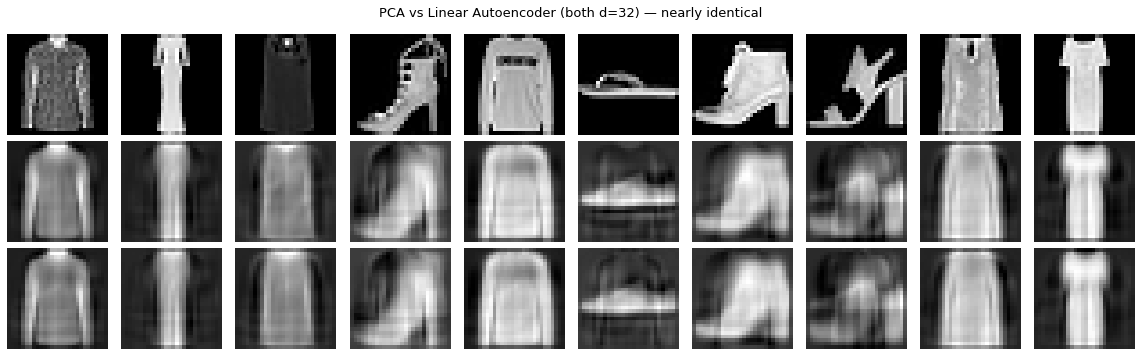

In [9]:
# Compare PCA vs Linear AE reconstructions
model_lin.eval()
with torch.no_grad():
    recon_ae, z_ae = model_lin(X_test.to(device))
    recon_ae = recon_ae.cpu().numpy()
    z_ae = z_ae.cpu().numpy()

pca32 = PCA(n_components=32).fit(X_train.numpy())
recon_pca = pca32.inverse_transform(pca32.transform(X_test.numpy()))

mse_ae  = np.mean((X_test.numpy() - recon_ae) ** 2)
mse_pca = np.mean((X_test.numpy() - recon_pca) ** 2)

fig, axes = plt.subplots(3, 10, figsize=(16, 5))
for i in range(10):
    axes[0, i].imshow(X_test[sample_idx[i]].reshape(28,28), cmap='gray'); axes[0,i].axis('off')
    axes[1, i].imshow(recon_pca[sample_idx[i]].reshape(28,28), cmap='gray'); axes[1,i].axis('off')
    axes[2, i].imshow(recon_ae[sample_idx[i]].reshape(28,28), cmap='gray'); axes[2,i].axis('off')

axes[0,0].set_ylabel('Original', fontsize=10, rotation=0, labelpad=55)
axes[1,0].set_ylabel(f'PCA\nMSE={mse_pca:.5f}', fontsize=9, rotation=0, labelpad=55)
axes[2,0].set_ylabel(f'Linear AE\nMSE={mse_ae:.5f}', fontsize=9, rotation=0, labelpad=55)
plt.suptitle('PCA vs Linear Autoencoder (both d=32) — nearly identical', fontsize=13)
plt.tight_layout(); plt.show()

The MSE values are nearly the same, and the reconstructions are visually indistinguishable. This confirms the theory: **a linear autoencoder learns the PCA subspace**. The difference is only up to a rotation within that subspace — the span is the same.

So if PCA and a linear autoencoder are equivalent, why bother with neural networks at all?

---
## 2. Non-linear autoencoders: adding activation functions

The answer: **add non-linearity**. By inserting activation functions (ReLU, sigmoid, etc.) between the layers, the encoder can learn curved, folded, non-linear projections that capture structure PCA cannot.

Think of it this way. PCA can only project onto flat planes. But the "manifold" of T-shirts doesn't sit on a flat plane in 784-dimensional space — it curves, bends, and folds. A non-linear encoder can follow that curvature.

The architecture is the same encode-bottleneck-decode structure, just deeper:

```
Encoder:  784 → 256 → 64 → latent_dim     (with ReLU between layers)
Decoder:  latent_dim → 64 → 256 → 784      (with ReLU + sigmoid at the end)
```

The final sigmoid squeezes outputs into [0, 1] — matching our pixel range.

In [10]:
class DeepAutoencoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(784, 256), nn.ReLU(),
            nn.Linear(256, 64),  nn.ReLU(),
            nn.Linear(64, latent_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),  nn.ReLU(),
            nn.Linear(64, 256),         nn.ReLU(),
            nn.Linear(256, 784),        nn.Sigmoid()
        )
    
    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z), z

def train_autoencoder(model, X_train, epochs=40, lr=1e-3, batch_size=256):
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    loader = DataLoader(TensorDataset(X_train), batch_size=batch_size, shuffle=True)
    
    history = []
    for epoch in range(epochs):
        epoch_loss = 0
        for (batch,) in loader:
            batch = batch.to(device)
            recon, _ = model(batch)
            loss = nn.MSELoss()(recon, batch)
            optimizer.zero_grad(); loss.backward(); optimizer.step()
            epoch_loss += loss.item() * len(batch)
        history.append(epoch_loss / len(X_train))
        if (epoch+1) % 10 == 0:
            print(f"  Epoch {epoch+1:3d}  loss = {history[-1]:.5f}")
    return history

In [11]:
# Train non-linear autoencoders at different bottleneck sizes
results = {}
for d in [2, 8, 32]:
    print(f"\n--- Latent dim = {d} ---")
    model = DeepAutoencoder(latent_dim=d)
    hist = train_autoencoder(model, X_train, epochs=40)
    
    model.eval()
    with torch.no_grad():
        recon, z = model(X_test.to(device))
        recon = recon.cpu().numpy()
        z = z.cpu().numpy()
    
    mse = np.mean((X_test.numpy() - recon) ** 2)
    results[d] = {'model': model, 'recon': recon, 'z': z, 'mse': mse, 'hist': hist}
    print(f"  Test MSE = {mse:.5f}")


--- Latent dim = 2 ---
  Epoch  10  loss = 0.02716
  Epoch  20  loss = 0.02583
  Epoch  30  loss = 0.02506
  Epoch  40  loss = 0.02459
  Test MSE = 0.02508

--- Latent dim = 8 ---
  Epoch  10  loss = 0.01587
  Epoch  20  loss = 0.01446
  Epoch  30  loss = 0.01385
  Epoch  40  loss = 0.01347
  Test MSE = 0.01378

--- Latent dim = 32 ---
  Epoch  10  loss = 0.01435
  Epoch  20  loss = 0.01199
  Epoch  30  loss = 0.01077
  Epoch  40  loss = 0.01006
  Test MSE = 0.01029


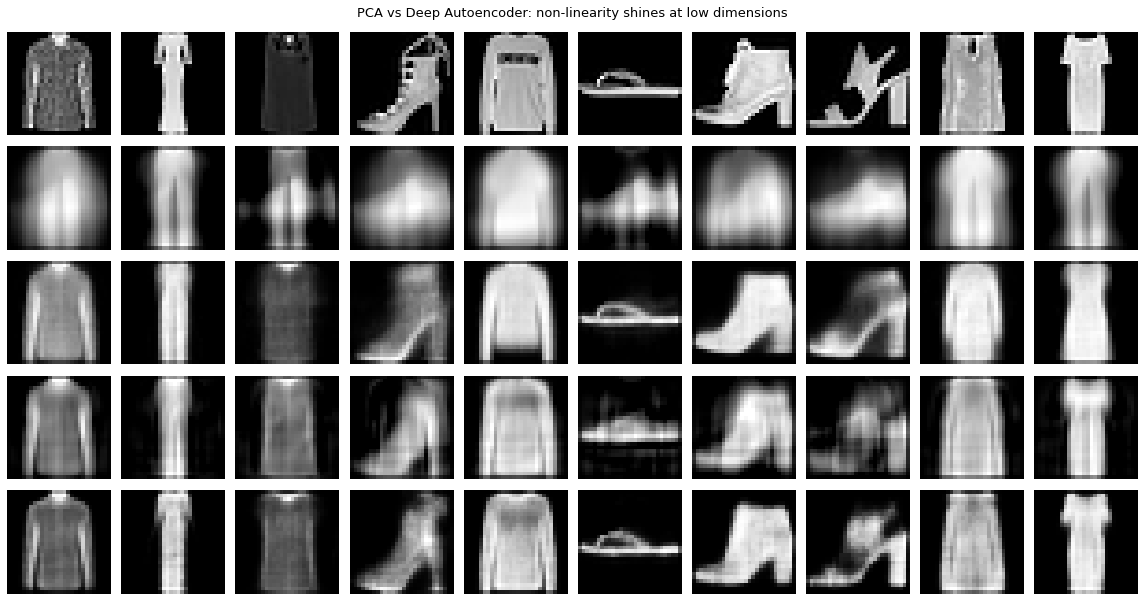

In [12]:
# Visual comparison: PCA vs Deep AE at d=2, d=32
fig, axes = plt.subplots(5, 10, figsize=(16, 8.5))

for i in range(10):
    axes[0, i].imshow(X_test[sample_idx[i]].reshape(28,28), cmap='gray')
    axes[0, i].axis('off')
axes[0, 0].set_ylabel('Original', fontsize=10, rotation=0, labelpad=60)

for row, (d, label) in enumerate([(2, 'PCA d=2'), (2, 'AE d=2'), (32, 'PCA d=32'), (32, 'AE d=32')]):
    if 'PCA' in label:
        pca_tmp = PCA(n_components=d).fit(X_train.numpy())
        recon_row = pca_tmp.inverse_transform(pca_tmp.transform(X_test.numpy()))
        mse_row = np.mean((X_test.numpy() - recon_row)**2)
    else:
        recon_row = results[d]['recon']
        mse_row = results[d]['mse']
    
    for i in range(10):
        img = np.clip(recon_row[sample_idx[i]].reshape(28,28), 0, 1)
        axes[row+1, i].imshow(img, cmap='gray')
        axes[row+1, i].axis('off')
    axes[row+1, 0].set_ylabel(f'{label}\nMSE={mse_row:.4f}', fontsize=9, rotation=0, labelpad=60)

plt.suptitle('PCA vs Deep Autoencoder: non-linearity shines at low dimensions', fontsize=13)
plt.tight_layout(); plt.show()

Two things to notice:

1. **At d=32**, PCA and the deep AE perform similarly — there's enough room in 32 dimensions to capture the structure even with linear projections.
2. **At d=2**, the deep AE is dramatically better. PCA with 2 components produces unrecognisable blobs. The AE produces blurry but recognisable clothing. With only 2 numbers to work with, non-linearity makes all the difference.

This is the core insight: **the bottleneck forces the network to learn a compressed representation**, and non-linear layers let it learn a much better one than any linear method could.

### The latent space: a new distance space

Remember from the clustering lectures: the quality of your analysis depends on the quality of the space you work in. The autoencoder's bottleneck creates a new space — the **latent space** — where each point is a compressed representation of an image.

Let's visualise the 2D latent space and colour by category. If the autoencoder has learned meaningful features, similar items should end up near each other.

C:\Users\Dilet\AppData\Local\Temp\ipykernel_19544\3148816052.py:19: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  handles = [plt.scatter([], [], c=plt.cm.tab10(i/10), s=30, label=class_names[i]) for i in range(10)]


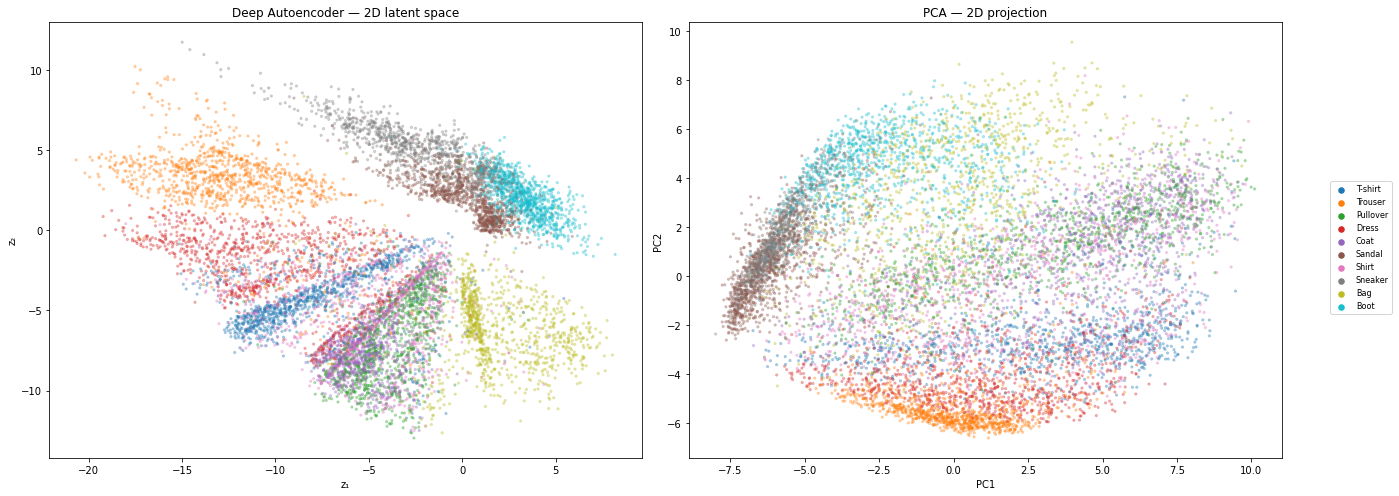

In [13]:
# 2D latent space from the d=2 autoencoder
z2d = results[2]['z']

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# AE latent space
scatter = axes[0].scatter(z2d[:, 0], z2d[:, 1], c=y_test, cmap='tab10', alpha=0.3, s=5)
axes[0].set_title('Deep Autoencoder — 2D latent space', fontsize=12)
axes[0].set_xlabel('z₁'); axes[0].set_ylabel('z₂')

# PCA space for comparison
pca_2 = PCA(n_components=2).fit(X_train.numpy())
z_pca = pca_2.transform(X_test.numpy())
axes[1].scatter(z_pca[:, 0], z_pca[:, 1], c=y_test, cmap='tab10', alpha=0.3, s=5)
axes[1].set_title('PCA — 2D projection', fontsize=12)
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')

# Shared legend
handles = [plt.scatter([], [], c=plt.cm.tab10(i/10), s=30, label=class_names[i]) for i in range(10)]
fig.legend(handles=handles, loc='center right', fontsize=8, bbox_to_anchor=(1.08, 0.5))
plt.tight_layout(); plt.show()

The AE latent space shows more separation between categories than PCA. Trousers, bags, and shoes form distinct clusters; T-shirts and shirts overlap (which makes sense — they look similar). This space is one where **Euclidean distance is more meaningful**: nearby points actually look alike.

You could now run K-Means or HDBSCAN on this latent space and get better clusters than on the raw 784 pixels. That's a recurring theme: autoencoders produce representations where your existing tools (distances, clustering, nearest neighbours) work better.

---
## 3. Denoising autoencoders: learning from corrupted data

So far our autoencoders learn to reconstruct $\mathbf{x}$ from $\mathbf{x}$. That works, but there's a risk: the network might memorise superficial pixel patterns instead of learning meaningful features. If we add a small amount of noise to the input but still ask the network to reconstruct the **clean** version, we force it to learn the underlying structure rather than surface details.

$$\tilde{\mathbf{x}} = \mathbf{x} + \epsilon, \quad \epsilon \sim \mathcal{N}(0, \sigma^2)$$

$$\mathcal{L} = \|\mathbf{x} - \text{decode}(\text{encode}(\tilde{\mathbf{x}}))\|^2$$

The input is noisy, but the target is clean. The only way to minimise this loss is to learn what the image *should* look like — stripping away the noise.

In [14]:
def train_denoising(model, X_train, noise_std=0.3, epochs=40, lr=1e-3, batch_size=256):
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    loader = DataLoader(TensorDataset(X_train), batch_size=batch_size, shuffle=True)
    
    history = []
    for epoch in range(epochs):
        epoch_loss = 0
        for (batch,) in loader:
            batch = batch.to(device)
            # Add noise to input, keep clean target
            noisy = batch + noise_std * torch.randn_like(batch)
            noisy = torch.clamp(noisy, 0, 1)
            
            recon, _ = model(noisy)
            loss = nn.MSELoss()(recon, batch)  # target is CLEAN
            optimizer.zero_grad(); loss.backward(); optimizer.step()
            epoch_loss += loss.item() * len(batch)
        history.append(epoch_loss / len(X_train))
        if (epoch+1) % 10 == 0:
            print(f"  Epoch {epoch+1:3d}  loss = {history[-1]:.5f}")
    return history

print("Training denoising autoencoder (d=32)...")
model_denoise = DeepAutoencoder(latent_dim=32)
hist_den = train_denoising(model_denoise, X_train, noise_std=0.3, epochs=40)

Training denoising autoencoder (d=32)...
  Epoch  10  loss = 0.01726
  Epoch  20  loss = 0.01479
  Epoch  30  loss = 0.01366
  Epoch  40  loss = 0.01299


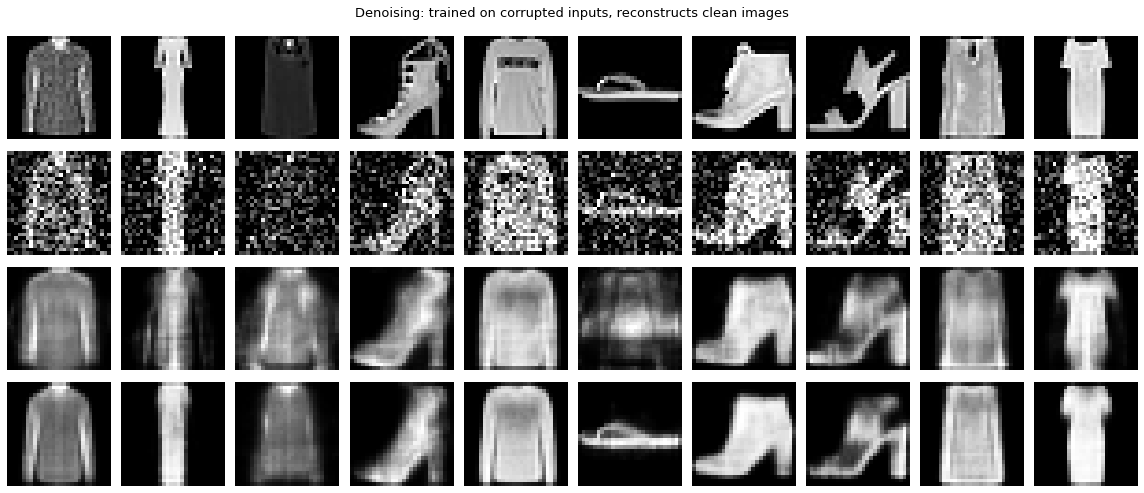

In [15]:
# Test: feed noisy images, compare outputs
model_denoise.eval()
noise_std = 0.3
X_noisy = X_test + noise_std * torch.randn_like(X_test)
X_noisy = torch.clamp(X_noisy, 0, 1)

with torch.no_grad():
    recon_denoise, _ = model_denoise(X_noisy.to(device))
    recon_denoise = recon_denoise.cpu().numpy()

# Also get standard AE reconstruction of noisy input for comparison
model_standard = results[32]['model']
model_standard.eval()
with torch.no_grad():
    recon_standard, _ = model_standard(X_noisy.to(device))
    recon_standard = recon_standard.cpu().numpy()

fig, axes = plt.subplots(4, 10, figsize=(16, 7))
for i in range(10):
    axes[0,i].imshow(X_test[sample_idx[i]].reshape(28,28), cmap='gray'); axes[0,i].axis('off')
    axes[1,i].imshow(X_noisy[sample_idx[i]].reshape(28,28), cmap='gray'); axes[1,i].axis('off')
    axes[2,i].imshow(np.clip(recon_standard[sample_idx[i]].reshape(28,28),0,1), cmap='gray'); axes[2,i].axis('off')
    axes[3,i].imshow(np.clip(recon_denoise[sample_idx[i]].reshape(28,28),0,1), cmap='gray'); axes[3,i].axis('off')

axes[0,0].set_ylabel('Clean', fontsize=10, rotation=0, labelpad=55)
axes[1,0].set_ylabel('Noisy input', fontsize=10, rotation=0, labelpad=55)
axes[2,0].set_ylabel('Standard AE', fontsize=10, rotation=0, labelpad=55)
axes[3,0].set_ylabel('Denoising AE', fontsize=10, rotation=0, labelpad=55)
plt.suptitle('Denoising: trained on corrupted inputs, reconstructs clean images', fontsize=13)
plt.tight_layout(); plt.show()

The denoising AE produces cleaner reconstructions than the standard AE when given noisy input. More importantly, its **latent representations are more robust** — small perturbations in the input don't cause large jumps in the latent space. This makes the latent space better for downstream tasks like clustering and nearest-neighbour search.

The connection to the collaborative filtering you've seen: imagine a user-item rating matrix with missing entries. A denoising autoencoder trained on randomly masked ratings learns to **fill in the gaps** — very similar to matrix factorisation, but non-linear. Netflix's recommendation engine used a variant of this approach.

---
## 4. Variational Autoencoders: from compression to generation

Standard autoencoders map each input to a **single point** in latent space. This is fine for compression and denoising, but it means the latent space has "gaps" — regions where no training data was encoded. If you pick a random point in one of those gaps and decode it, you get garbage.

Variational Autoencoders (VAEs) fix this by encoding each input not as a point, but as a **probability distribution** (a Gaussian). The encoder outputs two vectors: a mean $\boldsymbol{\mu}$ and a log-variance $\log \boldsymbol{\sigma}^2$. We then *sample* from this distribution to get the latent code:

$$\mathbf{z} = \boldsymbol{\mu} + \boldsymbol{\sigma} \odot \boldsymbol{\epsilon}, \quad \boldsymbol{\epsilon} \sim \mathcal{N}(0, I)$$

This is the **reparameterisation trick** — it lets gradients flow through the sampling step.

The loss has two terms:

$$\mathcal{L} = \underbrace{\|\mathbf{x} - \hat{\mathbf{x}}\|^2}_{\text{reconstruction}} + \beta \cdot \underbrace{D_{KL}(q(\mathbf{z}|\mathbf{x}) \| p(\mathbf{z}))}_{\text{regularisation}}$$

The first term is the usual reconstruction error. The second term — the **KL divergence** — penalises the encoder for producing distributions that are far from a standard Gaussian $\mathcal{N}(0, I)$. This does two things:
- It **fills the latent space** smoothly (no gaps)
- It makes the latent space **navigable**: nearby points decode to similar images

In [16]:
class VAE(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        # Encoder outputs mu and log_var (not a single point)
        self.enc_shared = nn.Sequential(
            nn.Linear(784, 256), nn.ReLU(),
            nn.Linear(256, 128), nn.ReLU()
        )
        self.fc_mu      = nn.Linear(128, latent_dim)
        self.fc_log_var = nn.Linear(128, latent_dim)
        
        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128), nn.ReLU(),
            nn.Linear(128, 256),        nn.ReLU(),
            nn.Linear(256, 784),        nn.Sigmoid()
        )
    
    def encode(self, x):
        h = self.enc_shared(x)
        return self.fc_mu(h), self.fc_log_var(h)
    
    def reparameterise(self, mu, log_var):
        # Sample z = mu + sigma * epsilon
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        return mu + std * eps
    
    def decode(self, z):
        return self.decoder(z)
    
    def forward(self, x):
        mu, log_var = self.encode(x)
        z = self.reparameterise(mu, log_var)
        return self.decode(z), mu, log_var, z

def vae_loss(recon, x, mu, log_var, beta=1.0):
    recon_loss = nn.MSELoss(reduction='sum')(recon, x)
    kl_loss = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())
    return recon_loss + beta * kl_loss

In [17]:
def train_vae(model, X_train, epochs=50, lr=1e-3, beta=1.0, batch_size=256):
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    loader = DataLoader(TensorDataset(X_train), batch_size=batch_size, shuffle=True)
    
    history = []
    for epoch in range(epochs):
        epoch_loss = 0
        for (batch,) in loader:
            batch = batch.to(device)
            recon, mu, log_var, _ = model(batch)
            loss = vae_loss(recon, batch, mu, log_var, beta=beta)
            optimizer.zero_grad(); loss.backward(); optimizer.step()
            epoch_loss += loss.item()
        history.append(epoch_loss / len(X_train))
        if (epoch+1) % 10 == 0:
            print(f"  Epoch {epoch+1:3d}  loss = {history[-1]:.3f}")
    return history

print("Training VAE (d=2)...")
vae_2d = VAE(latent_dim=2)
hist_vae_2d = train_vae(vae_2d, X_train, epochs=50, beta=1.0)

print("\nTraining VAE (d=16)...")
vae_16d = VAE(latent_dim=16)
hist_vae_16d = train_vae(vae_16d, X_train, epochs=50, beta=1.0)

Training VAE (d=2)...
  Epoch  10  loss = 28.023
  Epoch  20  loss = 27.033
  Epoch  30  loss = 26.502
  Epoch  40  loss = 26.189
  Epoch  50  loss = 25.931

Training VAE (d=16)...
  Epoch  10  loss = 24.924
  Epoch  20  loss = 23.974
  Epoch  30  loss = 23.559
  Epoch  40  loss = 23.349
  Epoch  50  loss = 23.220


### The VAE latent space is smooth and structured

C:\Users\Dilet\AppData\Local\Temp\ipykernel_19544\442869802.py:22: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  handles = [plt.scatter([], [], c=plt.cm.tab10(i/10), s=30, label=class_names[i]) for i in range(10)]


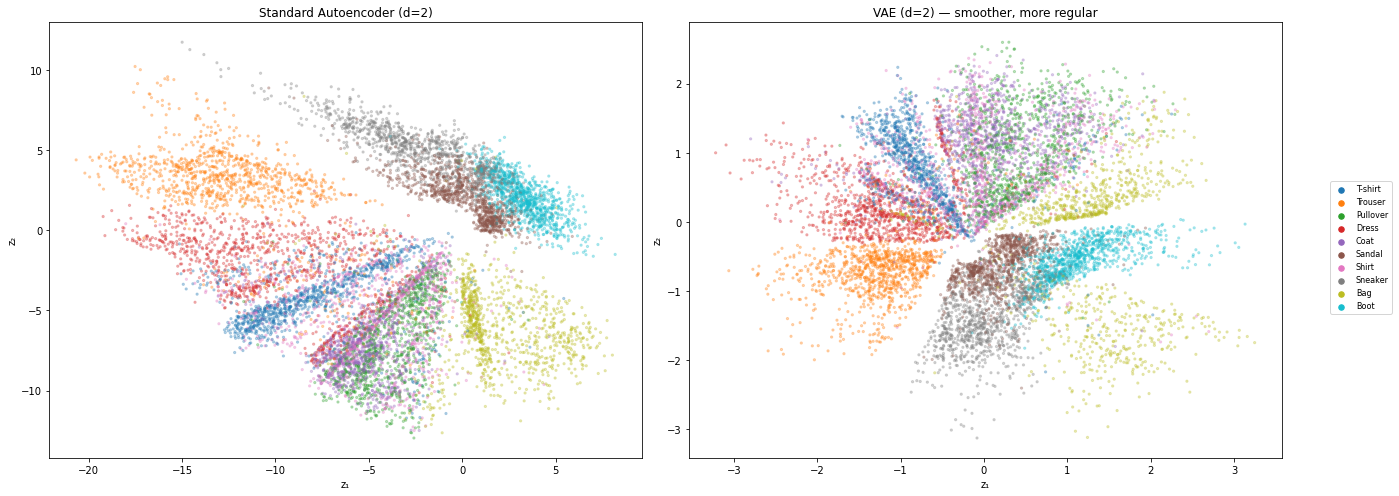

In [18]:
# Compare latent spaces: standard AE vs VAE (both 2D)
vae_2d.eval()
ae_2d = results[2]['model']
ae_2d.eval()

with torch.no_grad():
    _, mu_vae, _, z_vae = vae_2d(X_test.to(device))
    z_vae = mu_vae.cpu().numpy()  # use mean for plotting (more stable than samples)
    _, z_ae_2d = ae_2d(X_test.to(device))
    z_ae_2d = z_ae_2d.cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

axes[0].scatter(z_ae_2d[:, 0], z_ae_2d[:, 1], c=y_test, cmap='tab10', alpha=0.3, s=5)
axes[0].set_title('Standard Autoencoder (d=2)', fontsize=12)
axes[0].set_xlabel('z₁'); axes[0].set_ylabel('z₂')

axes[1].scatter(z_vae[:, 0], z_vae[:, 1], c=y_test, cmap='tab10', alpha=0.3, s=5)
axes[1].set_title('VAE (d=2) — smoother, more regular', fontsize=12)
axes[1].set_xlabel('z₁'); axes[1].set_ylabel('z₂')

handles = [plt.scatter([], [], c=plt.cm.tab10(i/10), s=30, label=class_names[i]) for i in range(10)]
fig.legend(handles=handles, loc='center right', fontsize=8, bbox_to_anchor=(1.08, 0.5))
plt.tight_layout(); plt.show()

The standard AE latent space has irregular shapes, sharp boundaries, and empty regions. The VAE latent space is smoother — the KL penalty pushes everything towards a Gaussian, so there are no big gaps. This means we can **sample random points** from the latent space and decode them into realistic images.

### Generating new images

This is what makes VAEs a *generative* model. We sample $\mathbf{z} \sim \mathcal{N}(0, I)$ and decode:

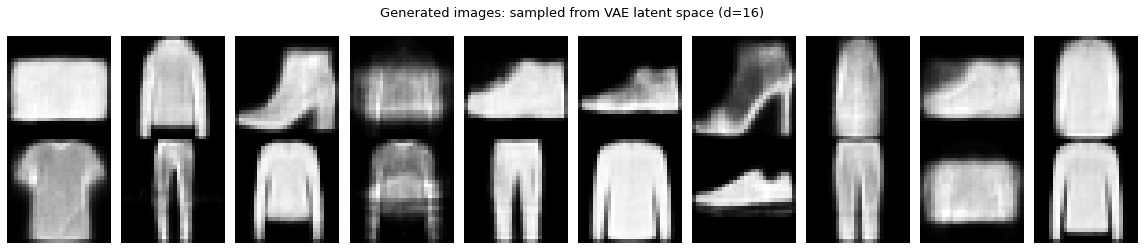

In [19]:
# Generate from random latent points
vae_16d.eval()
with torch.no_grad():
    z_random = torch.randn(20, 16).to(device)
    generated = vae_16d.decode(z_random).cpu().numpy()

fig, axes = plt.subplots(2, 10, figsize=(16, 3.5))
for i in range(20):
    axes[i//10, i%10].imshow(generated[i].reshape(28, 28), cmap='gray')
    axes[i//10, i%10].axis('off')
plt.suptitle('Generated images: sampled from VAE latent space (d=16)', fontsize=13)
plt.tight_layout(); plt.show()

These aren't copies of training images — they're **new** clothing items that the VAE has "imagined" by learning the statistical structure of the dataset. Some are blurry (a known limitation of VAEs), but they're recognisable as T-shirts, trousers, shoes, etc.

### Walking through latent space: interpolation

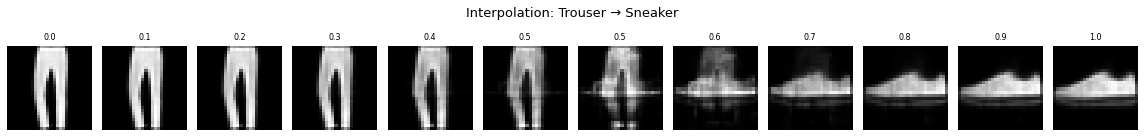

In [20]:
# Interpolate between two images
vae_16d.eval()

# Pick two distinct items
idx_a = np.where(y_test == 1)[0][0]  # Trouser
idx_b = np.where(y_test == 7)[0][0]  # Sneaker

with torch.no_grad():
    _, mu_a, _, _ = vae_16d(X_test[idx_a:idx_a+1].to(device))
    _, mu_b, _, _ = vae_16d(X_test[idx_b:idx_b+1].to(device))

# Linear interpolation in latent space
n_steps = 12
fig, axes = plt.subplots(1, n_steps, figsize=(16, 2))
for i, alpha in enumerate(np.linspace(0, 1, n_steps)):
    z_interp = (1 - alpha) * mu_a + alpha * mu_b
    with torch.no_grad():
        img = vae_16d.decode(z_interp).cpu().numpy()
    axes[i].imshow(img.reshape(28, 28), cmap='gray')
    axes[i].axis('off')
    axes[i].set_title(f'{alpha:.1f}', fontsize=8)

plt.suptitle(f'Interpolation: {class_names[y_test[idx_a]]} → {class_names[y_test[idx_b]]}', fontsize=13)
plt.tight_layout(); plt.show()

The transition is smooth — there are no sudden jumps or garbage in between. This is because the VAE's KL penalty ensures the latent space is **continuous**: nearby points decode to similar images. A standard autoencoder can't do this — its latent space has holes where the decoded output is unpredictable.

### For the 2D VAE: decoding a grid

With a 2D latent space we can visualise the entire manifold by decoding a grid of points:

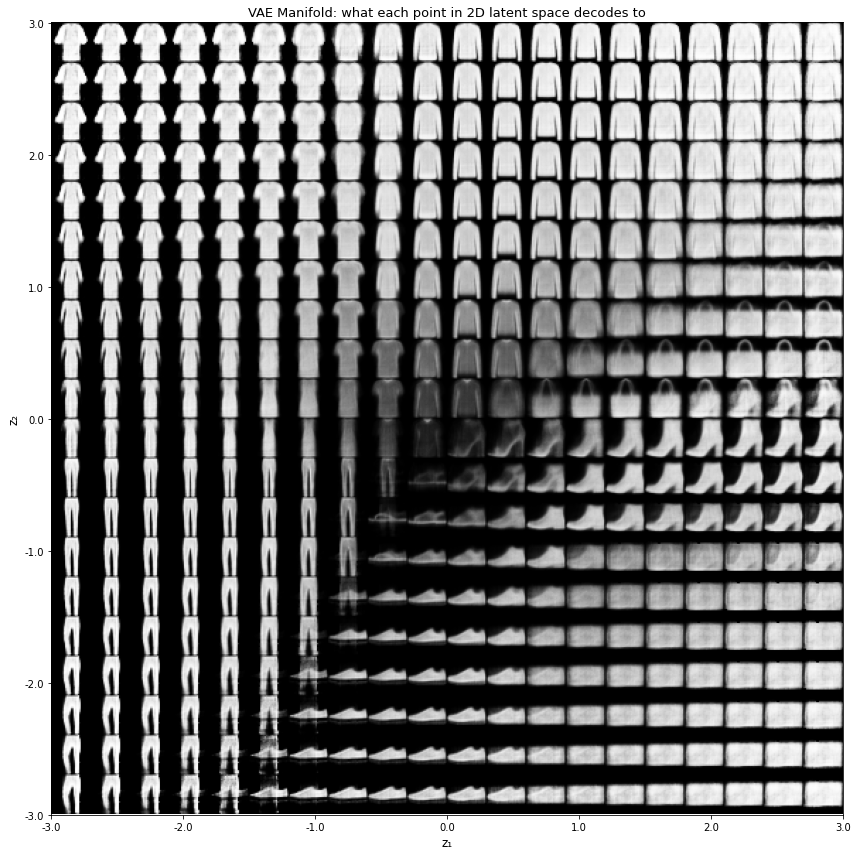

In [21]:
vae_2d.eval()

n = 20
grid_x = np.linspace(-3, 3, n)
grid_y = np.linspace(-3, 3, n)

canvas = np.zeros((28 * n, 28 * n))
for i, yi in enumerate(grid_y[::-1]):
    for j, xi in enumerate(grid_x):
        z = torch.tensor([[xi, yi]], dtype=torch.float32).to(device)
        with torch.no_grad():
            img = vae_2d.decode(z).cpu().numpy().reshape(28, 28)
        canvas[i*28:(i+1)*28, j*28:(j+1)*28] = img

fig, ax = plt.subplots(figsize=(12, 12))
ax.imshow(canvas, cmap='gray')
ax.set_xlabel('z₁', fontsize=12); ax.set_ylabel('z₂', fontsize=12)
ax.set_xticks(np.linspace(0, 28*n, 7))
ax.set_xticklabels([f'{x:.1f}' for x in np.linspace(-3, 3, 7)])
ax.set_yticks(np.linspace(0, 28*n, 7))
ax.set_yticklabels([f'{y:.1f}' for y in np.linspace(3, -3, 7)])
ax.set_title('VAE Manifold: what each point in 2D latent space decodes to', fontsize=13)
plt.tight_layout(); plt.show()

This is a map of the learned representation. Different regions correspond to different garment types, and moving smoothly across the map produces smooth transitions between them. The VAE has organised 784-dimensional images into a 2D space where **geometry reflects meaning**.

---
## Summary: the autoencoder family

| Method | Encoder | Decoder | Latent space | Can generate? |
|---|---|---|---|---|
| PCA | Linear (matrix multiply) | Linear (transpose) | Flat subspace | No |
| Linear AE | Linear (learned weights) | Linear (learned weights) | ≈ PCA subspace | No |
| Deep AE | Non-linear (ReLU layers) | Non-linear (ReLU + sigmoid) | Irregular manifold | No (gaps) |
| Denoising AE | Non-linear | Non-linear | Robust manifold | Not really |
| VAE | Non-linear → μ, σ² | Non-linear | Smooth Gaussian | **Yes** |

### Connections to what you already know

- **Dimensionality reduction**: autoencoders generalise PCA to non-linear manifolds, exactly as UMAP generalises linear projections. The latent space *is* a reduced representation.
- **Distances**: the latent space defines a new metric. Two images close in latent space are semantically similar, even if their pixel-level L2 distance is large (e.g., the same shoe shifted by a few pixels).
- **Clustering**: you can cluster in latent space. The compressed representation often gives cleaner clusters than raw features — the autoencoder has already filtered out noise.
- **Collaborative filtering**: a user-item matrix with missing entries is analogous to a noisy/incomplete image. Autoencoders can learn latent user and item factors, filling in the gaps — a non-linear generalisation of matrix factorisation.

### What comes next

Autoencoders are a foundation for several advanced architectures:
- **Generative Adversarial Networks (GANs)**: replace the pixel-wise loss with an adversarial discriminator → sharper images
- **Diffusion models** (Stable Diffusion, DALL-E): iteratively denoise random noise → state of the art image generation
- **Transformer autoencoders** (BERT): mask tokens in text, train to reconstruct → foundation of modern NLP
- **Contrastive learning**: instead of reconstructing, learn representations where similar pairs are close and dissimilar pairs are far → connects directly to the distance-based thinking you've been building all semester